In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('delay_analysis_data.csv')

In [5]:
df.head(3)

,_id_x,date,time,day,station,code,min_delay,min_gap,bound,line,...,datetime,incident_id,reason_id,year,month,hour,isdelayed,delaybucket,delay_category,gap_category
0,1,2025-01-01,2:10,Wednesday,BATHURST STATION,MUSAN,5,9,E,BD,...,2025-01-01 02:10:00,1,59,2025,1,2,1,1-5,Minor (1–5 min),Moderate Gap (6–15 min)
1,2,2025-01-01,2:30,Wednesday,DUNDAS STATION,MUIRS,0,0,Unknown,YU,...,2025-01-01 02:30:00,2,46,2025,1,2,0,0,No Delay,No Gap Issue
2,3,2025-01-01,2:32,Wednesday,BROADVIEW STATION,PUMST,0,0,E,BD,...,2025-01-01 02:32:00,3,75,2025,1,2,0,0,No Delay,No Gap Issue


#   Advance Analytics

# Delay Landscape Overview

In [7]:
delay_landscape = {
    "total_incidents": df.shape[0],
    "delayed_incidents": df["isdelayed"].sum(),
    "avg_delay_minutes": df.loc[df["isdelayed"] == 1, "min_delay"].mean(),
    "severe_delay_rate": (
        df["delay_category"] == "Severe (30+ min)"
    ).mean()
}

delay_landscape

{'total_incidents': 25581,
 'delayed_incidents': 8988,
 'avg_delay_minutes': 7.769359145527369,
 'severe_delay_rate': 0.007310112974473242}

~2.85% of incidents result in measurable delays, with severe disruptions accounting for 0.007% of cases

#  Pareto Analysis (80/20 Rule) 

# Do a small number of causes create most of the delays?

In [8]:
pareto = (
    df.groupby("description")["min_delay"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

pareto["cum_pct"] = pareto["min_delay"].cumsum() / pareto["min_delay"].sum()


In [9]:
pareto_top = pareto.head(15)

In [10]:
pareto_top

,description,min_delay,cum_pct
0,DISORDERLY PATRON,7658,0.109665
1,INJURED/ILL CUSTOMER ON TRAIN - MEDICAL AID RE...,4807,0.178502
2,UNAUTHORIZED AT TRACK LEVEL,3917,0.234595
3,INJURED/ILL CUSTOMER ON TRAIN - TRANSPORTED,3785,0.288797
4,OPTO (COMMUNICATIONS) TRAIN DOOR MONITORING,3426,0.337859
5,SECURITY OTHER,3418,0.386805
6,PAA - NO TROUBLE FOUND,2955,0.429122
7,WEATHER REPORTS / RELATED PROBLEMS,2745,0.468431
8,WORK ZONES PROBLEMS - TRACK,2341,0.501955
9,TRANSPORTATION OTHER,1935,0.529664


Top 15% of incident types account for nearly 70% of total delay minutes.

#  Frequency VS Impact matrix

# What happens often vs what hurts most?

In [11]:
impact = df.groupby("description").agg(
    frequency=("incident_id", "count"),
    impact=("min_delay", "sum")
).reset_index()

In [13]:
impact.head(10)

,description,frequency,impact
0,AIR CONDITIONING,16,124
1,ALTERNATING CURRENT,9,34
2,ANY ESCL. OR ELEV. INCIDENT - TRANSPORTED OR M...,817,0
3,ANY STAIRWAY INCIDENT - TRANSPORTED OR MEDICAL...,324,0
4,ASSAULT / EMPLOYEE INVOLVED,239,443
5,ASSAULT / SEXUAL,56,95
6,ASSUALT / PATRON INVOLVED,675,1759
7,ATC OPERATOR RELATED,77,229
8,ATC PROJECT,8,24
9,ATC RC&S EQUIPMENT,67,237


#  Station Risk Ranking

#  Where should TTC intervene first?

In [14]:
station_risk = df.groupby("station").agg(
    incidents=("incident_id", "count"),
    avg_delay=("min_delay", "mean"),
    severe_count=("delay_category", lambda x: (x == "Severe (30+ min)").sum())
)

In [17]:
station_risk = station_risk.sort_values(by='incidents', ascending=False)
station_risk.head(15)

,incidents,avg_delay,severe_count
station,,,
KENNEDY BD STATION,982,2.235234,10
BLOOR STATION,919,1.919478,5
FINCH STATION,898,2.033408,6
KIPLING STATION,864,2.609954,9
EGLINTON STATION,650,4.252308,5
WILSON STATION,629,3.438792,4
UNION STATION,585,2.476923,5
WARDEN STATION,573,2.815009,4
DUNDAS STATION,525,1.739048,2


#  Temporal Pattern Analysis (Peak vs Off-Peak)

#  When are riders most affected?

In [18]:
df["peak_period"] = df["hour"].between(7, 10) | df["hour"].between(16, 19)

df.groupby("peak_period").agg(
    incidents=("incident_id", "count"),
    avg_delay=("min_delay", "mean"),
    severe_rate=("delay_category", lambda x: (x == "Severe (30+ min)").mean())
)


,incidents,avg_delay,severe_rate
peak_period,,,
False,15784,2.642486,0.007286
True,9797,2.870471,0.007349


#  Pareto Chart on Few causes create most delay

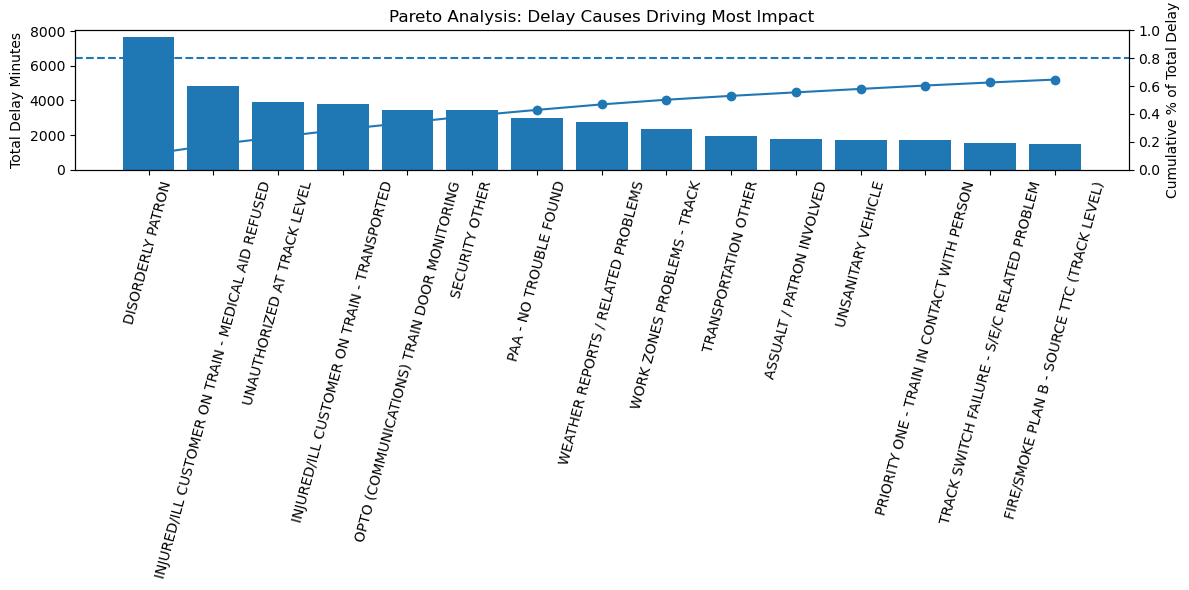

In [19]:

pareto = (
    df.groupby("description")["min_delay"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

pareto["cum_pct"] = pareto["min_delay"].cumsum() / pareto["min_delay"].sum()

pareto_top = pareto.head(15)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(pareto_top["description"], pareto_top["min_delay"])
ax1.set_ylabel("Total Delay Minutes")
ax1.set_title("Pareto Analysis: Delay Causes Driving Most Impact")
ax1.tick_params(axis='x', rotation=75)

ax2 = ax1.twinx()
ax2.plot(pareto_top["description"], pareto_top["cum_pct"], marker='o')
ax2.axhline(0.8, linestyle='--')
ax2.set_ylabel("Cumulative % of Total Delay")
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()


#  Frequency vs Impact Scatter (PRIORITIZATION MATRIX) 

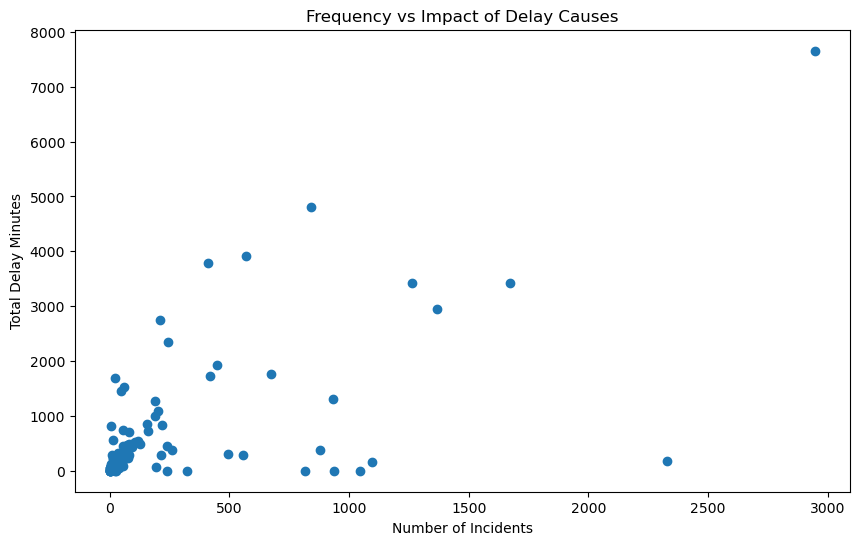

In [20]:
impact_freq = (
    df.groupby("description")
    .agg(
        frequency=("incident_id", "count"),
        impact=("min_delay", "sum")
    )
    .reset_index()
)

plt.figure(figsize=(10, 6))
plt.scatter(impact_freq["frequency"], impact_freq["impact"])
plt.xlabel("Number of Incidents")
plt.ylabel("Total Delay Minutes")
plt.title("Frequency vs Impact of Delay Causes")
plt.show()


#  Gap Category  to Delay Severity (CAUSE–EFFECT STORY)

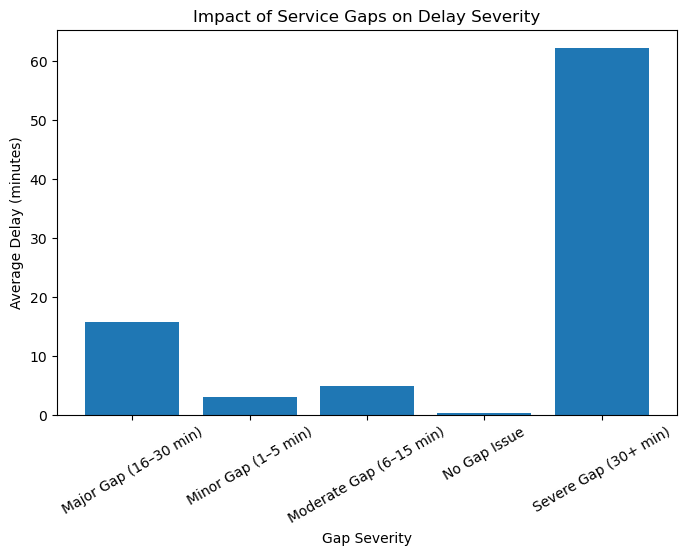

In [21]:
gap_delay = (
    df.groupby("gap_category")
    .agg(avg_delay=("min_delay", "mean"))
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.bar(gap_delay["gap_category"], gap_delay["avg_delay"])
plt.xlabel("Gap Severity")
plt.ylabel("Average Delay (minutes)")
plt.title("Impact of Service Gaps on Delay Severity")
plt.xticks(rotation=30)
plt.show()


#  Severe Delay Rate by Gap Category

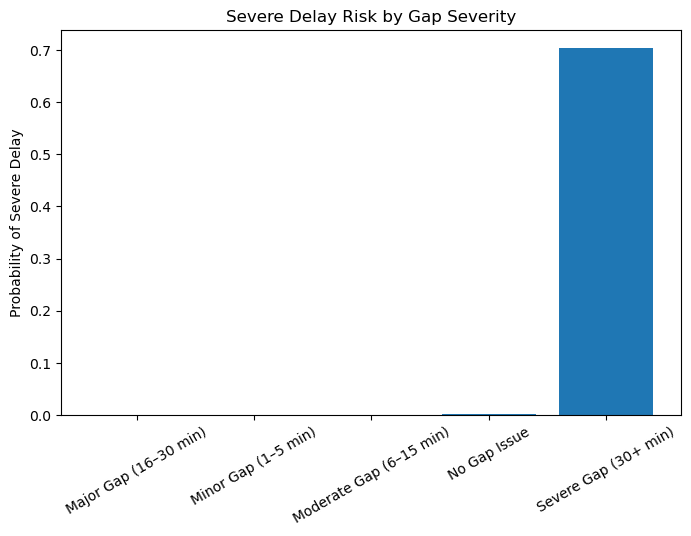

In [22]:
severe_rate = (
    df.assign(severe=df["delay_category"] == "Severe (30+ min)")
    .groupby("gap_category")["severe"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.bar(severe_rate["gap_category"], severe_rate["severe"])
plt.ylabel("Probability of Severe Delay")
plt.title("Severe Delay Risk by Gap Severity")
plt.xticks(rotation=30)
plt.show()


#  Top 10 Stations by Delay Volume

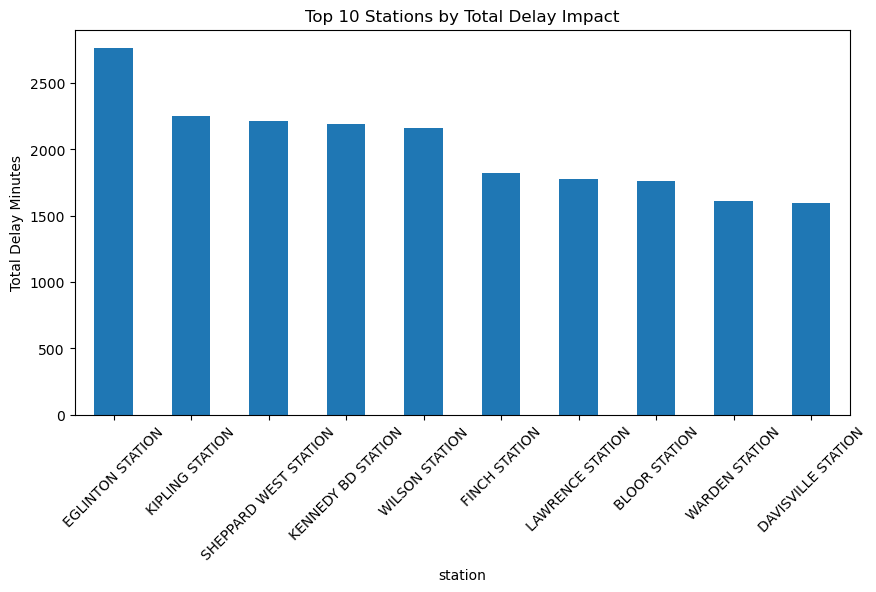

In [23]:
station_delay = (
    df.groupby("station")["min_delay"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
station_delay.plot(kind="bar")
plt.ylabel("Total Delay Minutes")
plt.title("Top 10 Stations by Total Delay Impact")
plt.xticks(rotation=45)
plt.show()


#  Line Comparison (BD vs YU)

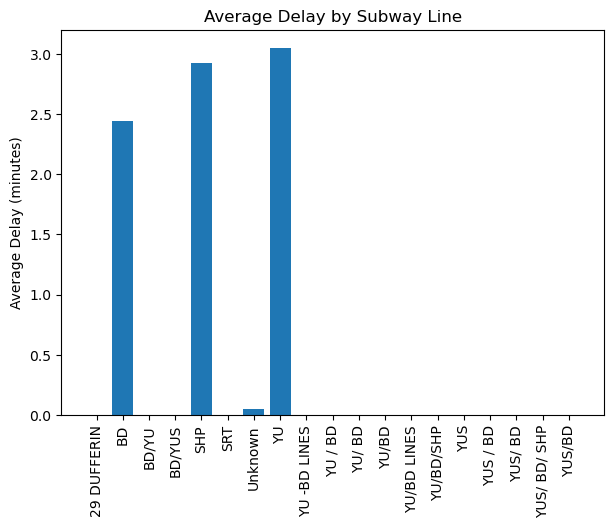

In [26]:
line_perf = (
    df.groupby("line")
    .agg(
        incidents=("incident_id", "count"),
        avg_delay=("min_delay", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(7, 5))
plt.bar(line_perf["line"], line_perf["avg_delay"])
plt.ylabel("Average Delay (minutes)")
plt.title("Average Delay by Subway Line")
plt.xticks(rotation=90)
plt.show()


#   Simple KPI Figure

In [27]:
kpi = {
    "Total Incidents": df.shape[0],
    "Delayed Incidents": df["isdelayed"].sum(),
    "Avg Delay (min)": round(df[df["isdelayed"] == 1]["min_delay"].mean(), 2)
}

kpi


{'Total Incidents': 25581, 'Delayed Incidents': 8988, 'Avg Delay (min)': 7.77}